# **Analyse et Ingénierie des données de la chlordécone aux Antilles françaises**

**Contexte général**

La chlordécone est un pesticide organochloré utilisé aux Antilles françaises jusqu’au début des années 1990. Sa persistance dans les sols, les eaux et les chaînes alimentaires en fait aujourd’hui un enjeu sanitaire, environnemental et socio-économique majeur.

Ce projet vise à exploiter des jeux de données réels ou réalistes (environnement, santé, agriculture, enquêtes, données spatiales et temporelles) afin de :

- structurer, nettoyer et transformer les données,

- mener des analyses statistiques et exploratoires avancées,

- produire des insights utiles à la prise de décision publique.

# Notebook 1 – Chargement & Découverte des Données

## Objectifs de ce notebook
- Charger le jeu de données `BaseCLD2026.csv`
- Explorer la structure du DataFrame
- Identifier les types de variables
- Produire aperçu/résumé statistique
- Visualiser les données

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Chemins relatifs pour la reproductibilité
NOTEBOOK_DIR = os.getcwd()
FIG_DIR = os.path.join(NOTEBOOK_DIR, 'fig', '1-chargement_decouverte')
os.makedirs(FIG_DIR, exist_ok=True)

print('Bibliothèques importées avec succès')

Bibliothèques importées avec succès


## 2. Chargement des données

In [2]:
# Chargement du fichier CSV (séparateur point-virgule, format français)
df = pd.read_csv(
    os.path.join(NOTEBOOK_DIR, 'BaseCLD2026.csv'),
    sep=';',
    parse_dates=['Date_prelevement', 'Date_enregistrement', 'Date_analyse']
)

# Conversion numérique des colonnes lues comme str (format décimal français)
cols_numeriques = ['Taux_Chlordecone', 'Taux_5b_hydro', 'histoBanane_Histo_ban',
                   'mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean',
                   'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean', 'X', 'Y']
for col in cols_numeriques:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'✅ Données chargées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head(5)

✅ Données chargées : 31,126 lignes × 22 colonnes


,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,...,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,NaN,2.0,5.805967,8.033367,21.593658,131.173998,79.447954,39.043098,714300.831892,1.626344e+06
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,NaN,2.0,5.683589,7.920563,20.944901,134.608205,76.985690,38.123675,714303.743345,1.626354e+06
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,NaN,3.0,2.239457,7.108432,20.085883,139.420523,76.064719,34.976678,714309.446765,1.626360e+06
3,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,NaN,1.0,4.038373,7.530090,23.427731,121.603678,92.392454,38.315796,714294.208512,1.626321e+06
4,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,2007-05-24,2007-05-24,2007-05-24,=,...,NaN,2.0,0.596502,6.637082,20.153770,134.065066,83.930611,33.877727,714303.823058,1.626341e+06


## 3. Structure du DataFrame

In [3]:
# Pour avoir une description plus détaillée, nous créeons un dataframe contenant nos colonnes avec leurs types, le nombre de valeurs manquantes et uniques
# Dataframe descriptif 
df_desc = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs manquantes': df.isnull().sum(),
    'Valeurs uniques': df.nunique()
})
print('Structure du DataFrame :')
df_desc

Structure du DataFrame :


,Type,Valeurs manquantes,Valeurs uniques
ID,int64,0,3619
ANNEE,int64,0,10
COMMU_LAB,str,298,35
RAIN,str,0,6
Sol_simple,str,74,7
type_sol,str,2609,41
Date_prelevement,datetime64[us],0,823
Date_enregistrement,datetime64[us],0,854
Date_analyse,datetime64[us],0,277
Operateur_chld,str,0,2


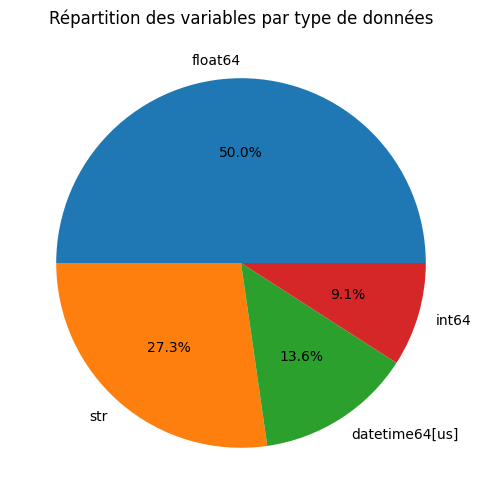

In [4]:
# Répartition des variables par type de données
type_counts = df.dtypes.value_counts()

# Représentation sous forme de diagramme circulaire
plt.figure(figsize=(8, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%') # Affiche les pourcentages sur le graphique
plt.title('Répartition des variables par type de données')
plt.show()

La représentation sous forme de diagramme circulaire nous permet de nous repérer et d'avoir un aperçu de la proportion de données à laquelle nous allons devoir nous intéresser pour cette étude.

## 4. Dictionnaire des variables

Le dictionnaire suivant provient du fichier ".docx" fourni au départ.



| Variable | Description |
|---|---|
| `ID` | Identifiant unique de la parcelle |
| `ANNEE` | Année d'observation (2010–2019) |
| `COMMU_LAB` | Commune où se situe la parcelle |
| `RAIN` | Groupe de pluviométrie |
| `Sol_simple` | Type de sol (classification simplifiée) |
| `type_sol` | Type de sol détaillé |
| `Date_prelevement` | Date de prélèvement du sol |
| `Date_enregistrement` | Date d'enregistrement au laboratoire |
| `Date_analyse` | Date d'analyse en laboratoire |
| `Operateur_chld` | Opérateur chlordécone |
| `Taux_Chlordecone` | **Taux de chlordécone mesuré (mg/kg)** |
| `Operateur_5b` | Opérateur 5b-hydro chlordécone |
| `Taux_5b_hydro` | Taux de 5b-hydro chlordécone |
| `histoBanane_Histo_ban` | Historique bananier |
| `mnt_tpi_mean` | Indice de position topographique (TPI) |
| `mnt_tri_mean` | Rugosité du terrain (TRI) |
| `mnt_rugosite_mean` | Rugosité moyenne |
| `mnt_ombrage_mean` | Ombrage moyen |
| `mnt_exposition_mean` | Exposition du terrain |
| `mnt_pente_mean` | Pente moyenne |
| `X` / `Y` | Coordonnées géographiques |

## 5. Statistiques descriptives

In [5]:
# Variables numériques
print('Statistiques descriptives – Variables numériques :')
df.describe().round(3) # Arondissement 3 chiffres après la virgule

Statistiques descriptives – Variables numériques :


,ID,ANNEE,Date_prelevement,Date_enregistrement,Date_analyse,Taux_Chlordecone,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
count,31126.000,31126.000,31126,31126,31126,31126.000,2060.0,13143.000,31098.000,31098.000,31098.000,31098.000,31098.000,31098.000,31126.000,31126.000
mean,38451.270,2015.319,2015-08-10 18:12:19.754546,2015-08-13 10:01:31.139240,2708-10-02 00:16:39.293192,0.668,inf,1.673,0.212,4.313,13.444,175.028,170.171,20.267,713040.204,1624037.205
min,20003.000,2010.000,2005-12-06 00:00:00,2005-12-06 00:00:00,2005-12-06 00:00:00,0.001,0.0,1.000,-29.066,0.000,0.000,24.789,0.000,0.000,690703.410,1594392.622
25%,21868.000,2013.000,2013-10-22 00:00:00,2013-10-22 00:00:00,2014-07-02 00:00:00,0.002,0.0,1.000,-0.875,2.375,7.500,159.391,89.759,10.797,703246.997,1614065.827
50%,23412.000,2016.000,2017-03-21 00:00:00,2017-02-23 00:00:00,2017-06-30 00:00:00,0.003,0.0,2.000,0.120,3.822,12.000,177.103,169.309,17.902,713492.101,1624495.598
75%,62783.750,2018.000,2018-05-15 00:00:00,2018-05-15 00:00:00,2018-11-20 00:00:00,0.410,NaN,2.000,1.267,5.625,17.764,193.293,249.272,27.097,721005.571,1633393.526
max,63714.000,2019.000,2019-07-23 00:00:00,2019-07-23 00:00:00,9999-12-30 00:00:00,17.350,inf,3.000,26.012,29.358,85.396,255.000,359.145,124.950,734338.584,1645435.314
std,19380.547,2.816,NaN,NaN,NaN,1.560,NaN,0.732,2.580,2.859,8.626,27.894,95.738,13.374,9887.780,11773.841


In [6]:
# variables catégorielles et leurs modalités
cat_cols = df.select_dtypes(include='object').columns  # Sélectionne les colonnes de type "object"  soit catégorielles
print('Modalités des variables catégorielles :\n')
for col in cat_cols: 
    modalites = ', '.join(str(v) for v in df[col].dropna().unique()[:6]) # Affiche les 8 premières modalités (pour éviter d'avoir une liste trop longue)
    print(f' # {col} ({df[col].nunique()} modalités) : {modalites}') 

Modalités des variables catégorielles :

 # COMMU_LAB (35 modalités) : GROS-MORNE, DUCOS, SAINTE-MARIE, LORRAIN(LE), ROBERT(LE), VAUCLIN(LE)
 # RAIN (6 modalités) : 2000-3000, 1500-2000, 3000-5000, 1250-1500, 0-1250, 5000-8000
 # Sol_simple (7 modalités) : Andosol, Ferralsol, Nitisol, Alluvium, Colluvium, No data, Vertisol
 # type_sol (41 modalités) : Intergrades Sols … allophane relativement ‚volu‚s/Ferrisols compacts, Ferrisols compacts, Sols bruns-rouille … halloysite, Colluvions, Sols … allophane relativement peu ‚volu‚s, Vertisols  USTIC
 # Operateur_chld (2 modalités) : =, <
 # Operateur_5b (2 modalités) : =, <


## 6. Distribution de la variable cible : `Taux_Chlordecone`

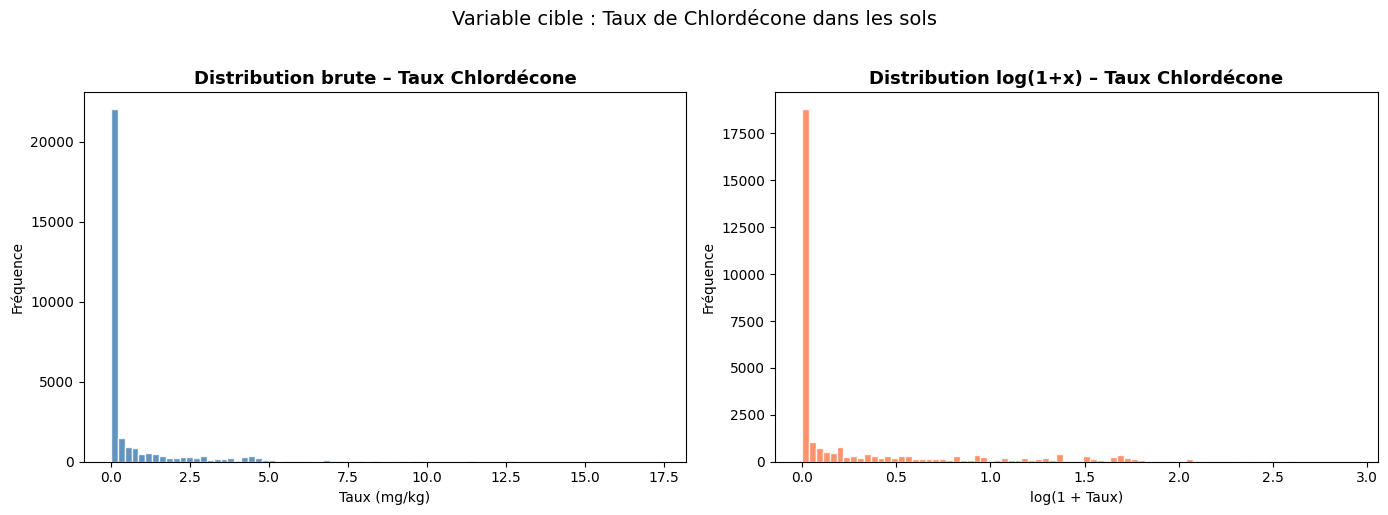

Figure sauvegardée.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df['Taux_Chlordecone'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution brute – Taux Chlordécone', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Taux (mg/kg)')
axes[0].set_ylabel('Fréquence')

# Distribution en log (réduit l'impact des valeurs extrêmes)
log_vals = np.log1p(df['Taux_Chlordecone'])
axes[1].hist(log_vals, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution log(1+x) – Taux Chlordécone', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Taux)')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Variable cible : Taux de Chlordécone dans les sols', fontsize=14, y=1.02)
plt.tight_layout()
# Chemin relatif pour la reproductibilité
plt.savefig(os.path.join(FIG_DIR, 'fig_distribution_chlordecone.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

## 7. Répartition temporelle et géographique

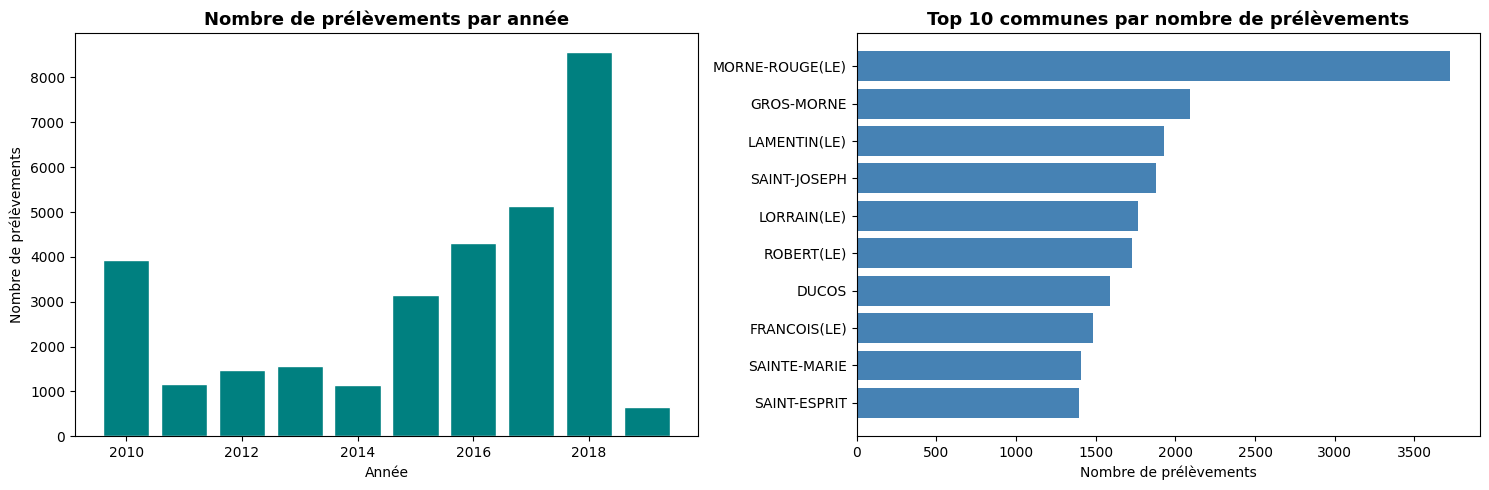

Figure sauvegardée.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Répartition par année
annee_counts = df['ANNEE'].value_counts().sort_index()
axes[0].bar(annee_counts.index, annee_counts.values, color='teal', edgecolor='white')
axes[0].set_title('Nombre de prélèvements par année', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre de prélèvements')

# Top 10 communes par nombre de prélèvements
top_communes = df['COMMU_LAB'].value_counts().head(10)
axes[1].barh(top_communes.index[::-1], top_communes.values[::-1], color='steelblue')
axes[1].set_title('Top 10 communes par nombre de prélèvements', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de prélèvements')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_geo_temp.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

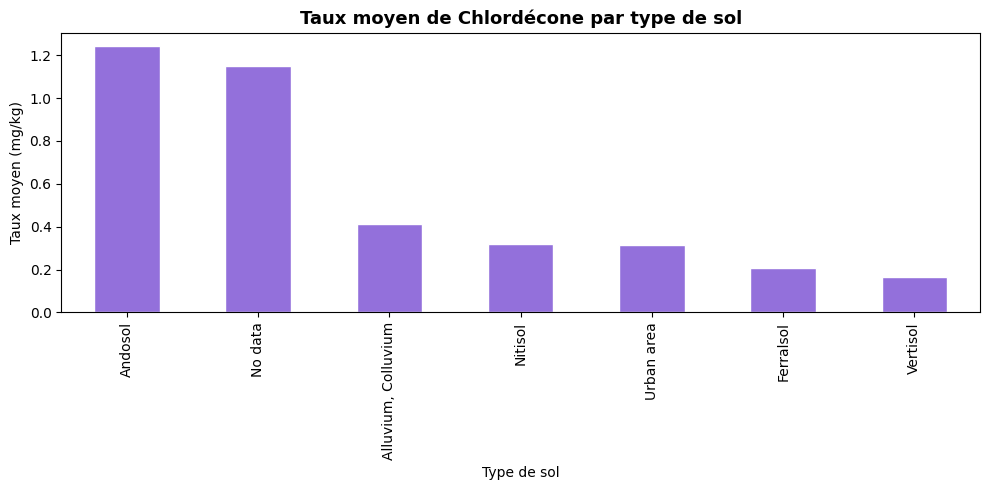

Figure sauvegardée.


In [9]:
# Taux moyen par type de sol
taux_sol = df.groupby('Sol_simple')['Taux_Chlordecone'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
taux_sol.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Taux moyen de Chlordécone par type de sol', fontsize=13, fontweight='bold')
plt.xlabel('Type de sol')
plt.ylabel('Taux moyen (mg/kg)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_taux_par_sol.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

## 8. Carte des coordonnées géographiques

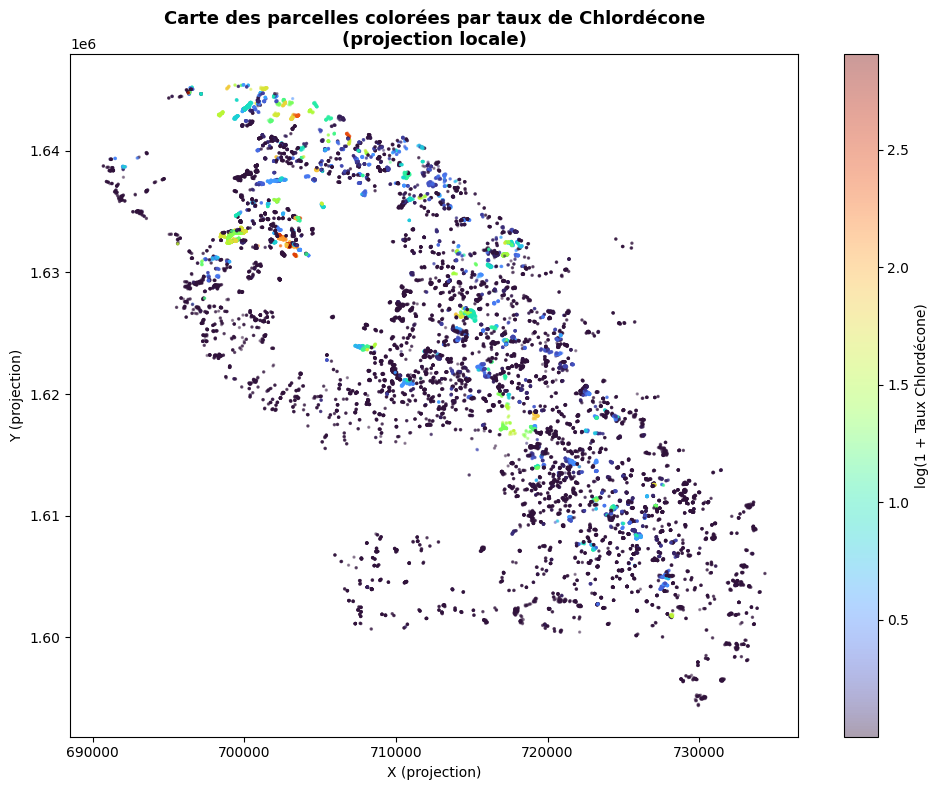

Figure sauvegardée.


In [10]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df['X'], df['Y'],
    c=np.log1p(df['Taux_Chlordecone']),
    cmap='turbo', alpha=0.4, s=2
)
plt.colorbar(sc, label='log(1 + Taux Chlordécone)')
plt.title('Carte des parcelles colorées par taux de Chlordécone\n(projection locale)',
          fontsize=13, fontweight='bold')
plt.xlabel('X (projection)')
plt.ylabel('Y (projection)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_carte_chlordecone.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

## 9. Synthèse

| Indicateur | Valeur |
|---|---|
| Nombre de lignes | 31 126 |
| Nombre de colonnes | 22 |
| Période couverte | 2010 – 2019 |
| Taux Chlordécone moyen | ~0.67 mg/kg |
| Taux Chlordécone médian | ~0.003 mg/kg |
| Taux Chlordécone max | 17.35 mg/kg |
| Colonnes avec valeurs manquantes | 9 / 22 |

On peut à présent passer au deuxième notebook dans lequel nous allons effectuer un nettoyage des données.